# 01 - Qubits and gates

Starting point for getting qiskit to do things. The physics here is standard - a qubit is a two level system, state is a unit vector in C^2, gates are unitaries. Im mostly interested in getting comfortable with how qiskit represents all of this before moving to anything nontrivial.

A general state is alpha|0> + beta|1> with |alpha|^2 + |beta|^2 = 1. Measurement gives 0 with probability |alpha|^2 and collapses the state. Nothing new here, the interesting part is how to work with this computationally.

In [1]:
print("Working")

Working


In [2]:
!pip install qiskit
!pip install qiskit_aer
!pip install pylatexenc


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit.quantum_info import Statevector

import warnings
warnings.filterwarnings('ignore')

## State vectors and gates in numpy

Before touching qiskit, its cleaner to just work with numpy. The Pauli matrices generate SU(2) and single qubit gates are rotations on the Bloch sphere:

$$R_n(\theta) = e^{-i\theta/2 \, \hat{n}\cdot\vec{\sigma}} = \cos\frac{\theta}{2}\, I - i\sin\frac{\theta}{2}\, \hat{n}\cdot\vec{\sigma}$$

H, X, Z etc are just specific rotations. H is a pi rotation around the (X+Z)/sqrt(2) axis, which swaps the Z and X axes on the Bloch sphere.

In [4]:
ket0 = np.array([1,0], dtype=complex)
ket1 = np.array([0,1], dtype=complex)

I = np.eye(2, dtype=complex)
X = np.array([[0,1],[1,0]], dtype=complex)
Y = np.array([[0,-1j],[1j,0]], dtype=complex)
Z = np.array([[1,0],[0,-1]], dtype=complex)
H = np.array([[1,1],[1,-1]], dtype=complex) / np.sqrt(2)

def Rx(t): return np.cos(t/2)*I - 1j*np.sin(t/2)*X
def Ry(t): return np.cos(t/2)*I - 1j*np.sin(t/2)*Y
def Rz(t): return np.cos(t/2)*I - 1j*np.sin(t/2)*Z

# H = Rz(pi/2) Ry(pi/2) Rz(pi/2) up to global phase
H_decomp = Rz(np.pi/2) @ Ry(np.pi/2) @ Rz(np.pi/2)
print('same up to phase:', np.allclose(np.abs(H_decomp), np.abs(H)))

# unitarity
for name, U in [('X',X),('Y',Y),('Z',Z),('H',H),('Rx(pi/3)',Rx(np.pi/3))]:
    print(name, 'unitary:', np.allclose(U @ U.conj().T, I))

same up to phase: True
X unitary: True
Y unitary: True
Z unitary: True
H unitary: True
Rx(pi/3) unitary: True


Every single qubit gate can be decomposed as Rz Ry Rz (Euler decomposition). In qiskit this is the U gate with parameters (theta, phi, lambda). Worth knowing when you start looking at circuit transpilation.

## Qiskit basics

In qiskit a circuit is built gate by gate. Qubits initialise in |0> by default. The main simulator is AerSimulator - can do statevector, density matrix or shot-based sampling. For now just shots.

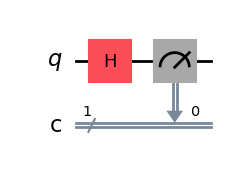

In [5]:
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

qc.draw('mpl')

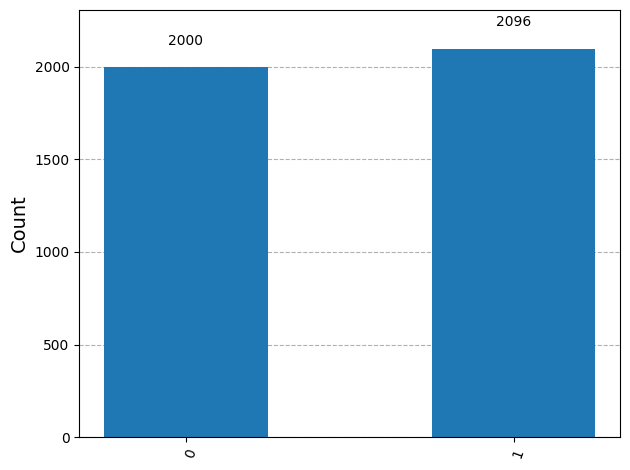

In [6]:
sim = AerSimulator()
counts = sim.run(qc, shots=4096).result().get_counts()
plot_histogram(counts)

[0.70710678+0.j 0.70710678+0.j]


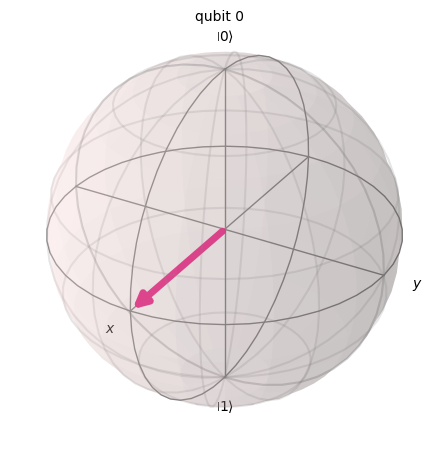

In [7]:
# to get the actual statevector, use Statevector directly on the circuit
# no measurement in the circuit for this to work
qc_sv = QuantumCircuit(1)
qc_sv.h(0)

sv = Statevector(qc_sv)
print(sv.data)
plot_bloch_multivector(sv)

## Bloch sphere

Any pure state is a point on the unit sphere via
$$|\psi\rangle = \cos\frac{\theta}{2}|0\rangle + e^{i\phi}\sin\frac{\theta}{2}|1\rangle$$
North pole is |0>, south is |1>, equator is equal superpositions with varying relative phase. H swaps Z and X axes, Z is a pi rotation around Z, X flips between poles.

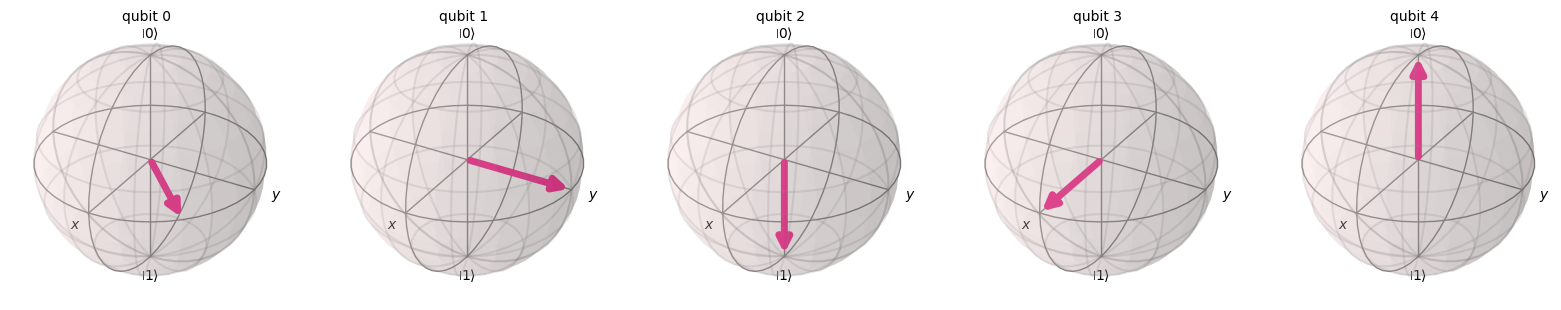

In [9]:
states = []
for gates in [[], ['h'], ['x'], ['h','s'], ['h','t']]:
    qc_tmp = QuantumCircuit(1)
    for g in gates:
        getattr(qc_tmp, g)(0)
    states.append(Statevector(qc_tmp))

# Combine all states into a single multi-qubit statevector
combined_state = states[0]
for state in states[1:]:
    combined_state = combined_state.tensor(state)

plot_bloch_multivector(combined_state)

## Preparing states with specific probabilities

Ry(theta)|0> = cos(theta/2)|0> + sin(theta/2)|1>, so to prepare a state with P(0) = p just set theta = 2*arccos(sqrt(p)).

In [10]:
theta = np.pi / 3
p0_theory = np.cos(theta/2)**2

qc_arb = QuantumCircuit(1,1)
qc_arb.ry(theta, 0)
qc_arb.measure(0,0)

counts = sim.run(qc_arb, shots=8192).result().get_counts()
p0_sim = counts.get('0',0) / 8192

print(f'theory: {p0_theory:.4f}')
print(f'sim:    {p0_sim:.4f}')

theory: 0.7500
sim:    0.7500
